In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

%matplotlib inline

# Import FlowPDE modules
from flowpde import (
    PoissonInverseDataset, FlowDatasetWrapper,
    UNet, FlowMatching, FlowMatchingTrainer, ODEFlowSolver
)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'mps')
print(f"Using device: {device}")

# Set random seed
torch.manual_seed(42)
np.random.seed(42)

Using device: mps


## 2. Load Dataset

**Inverse Problem:** observation u → (source f, coefficient a)

**Dataset Returns:**
- `input`: observation u (1, H, W)
- `target`: concatenated [source, coefficient] (2, H, W)

**Flow Training Expects:**
- `f`: observation (condition)
- `u`: parameters (target)

In [2]:
# Load dataset
data_path = '../data/datasets/poisson/inverse/train_32.pt'
batch_size = 32

dataset = PoissonInverseDataset(
    data_path=data_path,
    normalize=True,
    return_dict=True
)

# Wrap for flow training
wrapped_dataset = FlowDatasetWrapper(dataset)

train_loader = DataLoader(
    wrapped_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

print(f"Dataset size: {len(dataset)} samples")
print(f"Number of batches: {len(train_loader)}")

# Inspect sample
sample = wrapped_dataset[0]
print(f"\nSample data:")
print(f"  Observation (f) shape: {sample['f'].shape}")  # (1, H, W)
print(f"  Parameters (u) shape: {sample['u'].shape}")   # (2, H, W)

Dataset size: 15 samples
Number of batches: 1

Sample data:
  Observation (f) shape: torch.Size([1, 32, 32])
  Parameters (u) shape: torch.Size([2, 32, 32])


## 3. Visualize Data

Batch shapes:
  Observations: torch.Size([15, 1, 32, 32])
  Parameters: torch.Size([15, 2, 32, 32])


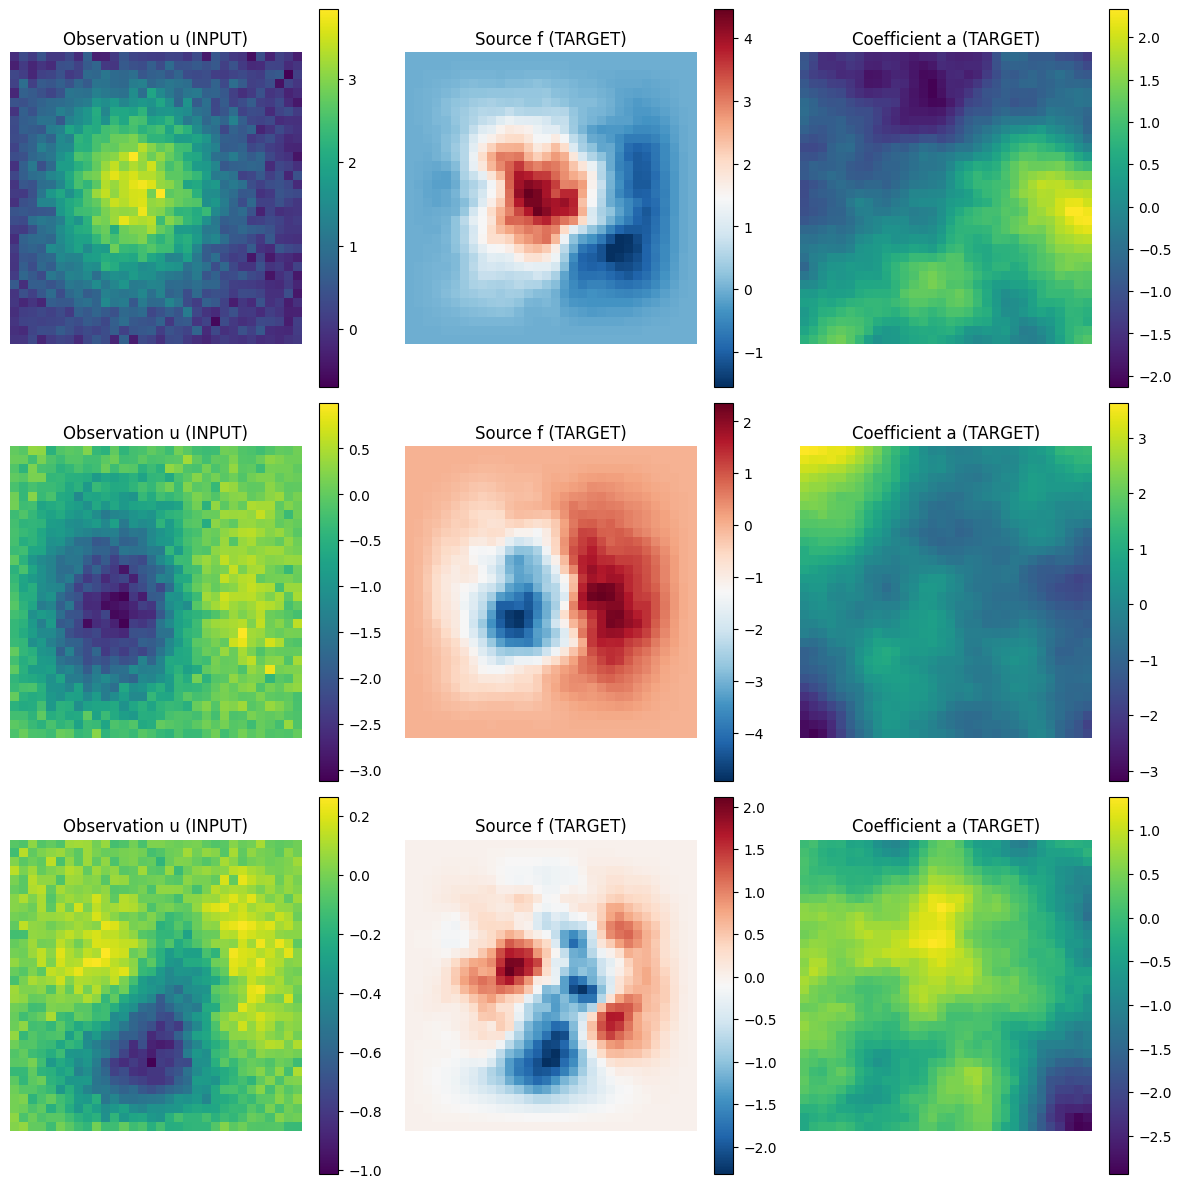

In [3]:
# Get a batch
batch = next(iter(train_loader))
observations = batch['f']  # Condition (input)
parameters = batch['u']    # Target (source + coefficient)

print(f"Batch shapes:")
print(f"  Observations: {observations.shape}")  # (batch, 1, H, W)
print(f"  Parameters: {parameters.shape}")      # (batch, 2, H, W)

# Visualize
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):
    obs = observations[i, 0].numpy()
    source = parameters[i, 0].numpy()
    coeff = parameters[i, 1].numpy()
    
    im1 = axes[i, 0].imshow(obs, cmap='viridis')
    axes[i, 0].set_title(f'Observation u (INPUT)')
    axes[i, 0].axis('off')
    plt.colorbar(im1, ax=axes[i, 0])
    
    im2 = axes[i, 1].imshow(source, cmap='RdBu_r')
    axes[i, 1].set_title(f'Source f (TARGET)')
    axes[i, 1].axis('off')
    plt.colorbar(im2, ax=axes[i, 1])
    
    im3 = axes[i, 2].imshow(coeff, cmap='viridis')
    axes[i, 2].set_title(f'Coefficient a (TARGET)')
    axes[i, 2].axis('off')
    plt.colorbar(im3, ax=axes[i, 2])

plt.tight_layout()
plt.show()

## 4. Create Model

In [4]:
# Model configuration
grid_size = observations.shape[2]
observation_dim = observations.shape[1] * grid_size * grid_size  # 1 * H * W
parameters_dim = parameters.shape[1] * grid_size * grid_size     # 2 * H * W

print(f"Grid size: {grid_size}x{grid_size}")
print(f"Observation dimension: {observation_dim}")
print(f"Parameters dimension: {parameters_dim}")

# Create UNet model
model = UNet(
    input_dim=observation_dim + parameters_dim,
    base_ch=64,
    time_dim=1,
    use_attention=True,
    solution_channels=2,
    condition_channels=1
)

num_params = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters: {num_params:,}")

Grid size: 32x32
Observation dimension: 1024
Parameters dimension: 2048

Model parameters: 35,485,890


## 5. Create Flow and Trainer

In [5]:
# Create Flow Matching instance
flow = FlowMatching(model=model, path='linear', sigma=0.0)

# Optimizer and scheduler
learning_rate = 1e-4
epochs = 50
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# Create trainer
trainer = FlowMatchingTrainer(
    flow=flow,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device
)

print("Flow Matching Trainer created successfully!")

Flow Matching Trainer created successfully!


## 6. Train the Model

In [6]:
save_dir = '../results/training/poisson_inverse_notebook'

print("Starting training...")
print("="*60)

trainer.train(
    data_loader=train_loader,
    epochs=epochs,
    print_stats_interval=5,
    save_interval=10,
    save_dir=save_dir
)

print("\nTraining complete!")

Starting training...
Epoch: 0001/50 | Train_Loss: 2.148676 | LR: 9.99e-05 | Time: 8.663938
Epoch: 0006/50 | Train_Loss: 1.380554 | LR: 9.65e-05 | Time: 0.18807
Epoch: 0011/50 | Train_Loss: 1.31063 | LR: 8.85e-05 | Time: 0.230244
Epoch: 0016/50 | Train_Loss: 1.012491 | LR: 7.68e-05 | Time: 0.208218
Epoch: 0021/50 | Train_Loss: 0.945498 | LR: 6.24e-05 | Time: 0.747845
Epoch: 0026/50 | Train_Loss: 0.871169 | LR: 4.69e-05 | Time: 0.158777
Epoch: 0031/50 | Train_Loss: 0.89625 | LR: 3.16e-05 | Time: 0.169983
Epoch: 0036/50 | Train_Loss: 0.711474 | LR: 1.81e-05 | Time: 0.1787
Epoch: 0041/50 | Train_Loss: 0.693293 | LR: 7.78e-06 | Time: 0.279637
Epoch: 0046/50 | Train_Loss: 0.808013 | LR: 1.57e-06 | Time: 0.160668
Saved loss curve to ../results/training/poisson_inverse_notebook/training_curve.png

Best loss: 0.671260
Best model saved to: ../results/training/poisson_inverse_notebook/best_model.pt

Training complete!


## 7. Generate Samples

In [7]:
model.eval()

# Get test batch
test_batch = next(iter(train_loader))
true_observations = test_batch['f'].to(device)
true_parameters = test_batch['u'].to(device)

# Create ODE solver
ode_solver = ODEFlowSolver(
    model=model,
    method='dopri5',
    rtol=1e-5,
    atol=1e-7
)

# Generate samples
with torch.no_grad():
    z = torch.randn_like(true_parameters).to(device)
    generated_parameters = ode_solver.sample(
        condition=true_observations,
        x_init=z,
        n_steps=50
    )

print(f"Generated {generated_parameters.shape[0]} samples")
print(f"True parameters range: [{true_parameters.min():.3f}, {true_parameters.max():.3f}]")
print(f"Generated parameters range: [{generated_parameters.min():.3f}, {generated_parameters.max():.3f}]")

Generated 15 samples
True parameters range: [-6.642, 4.461]
Generated parameters range: [-5.439, 3.987]


## 8. Visualize Results

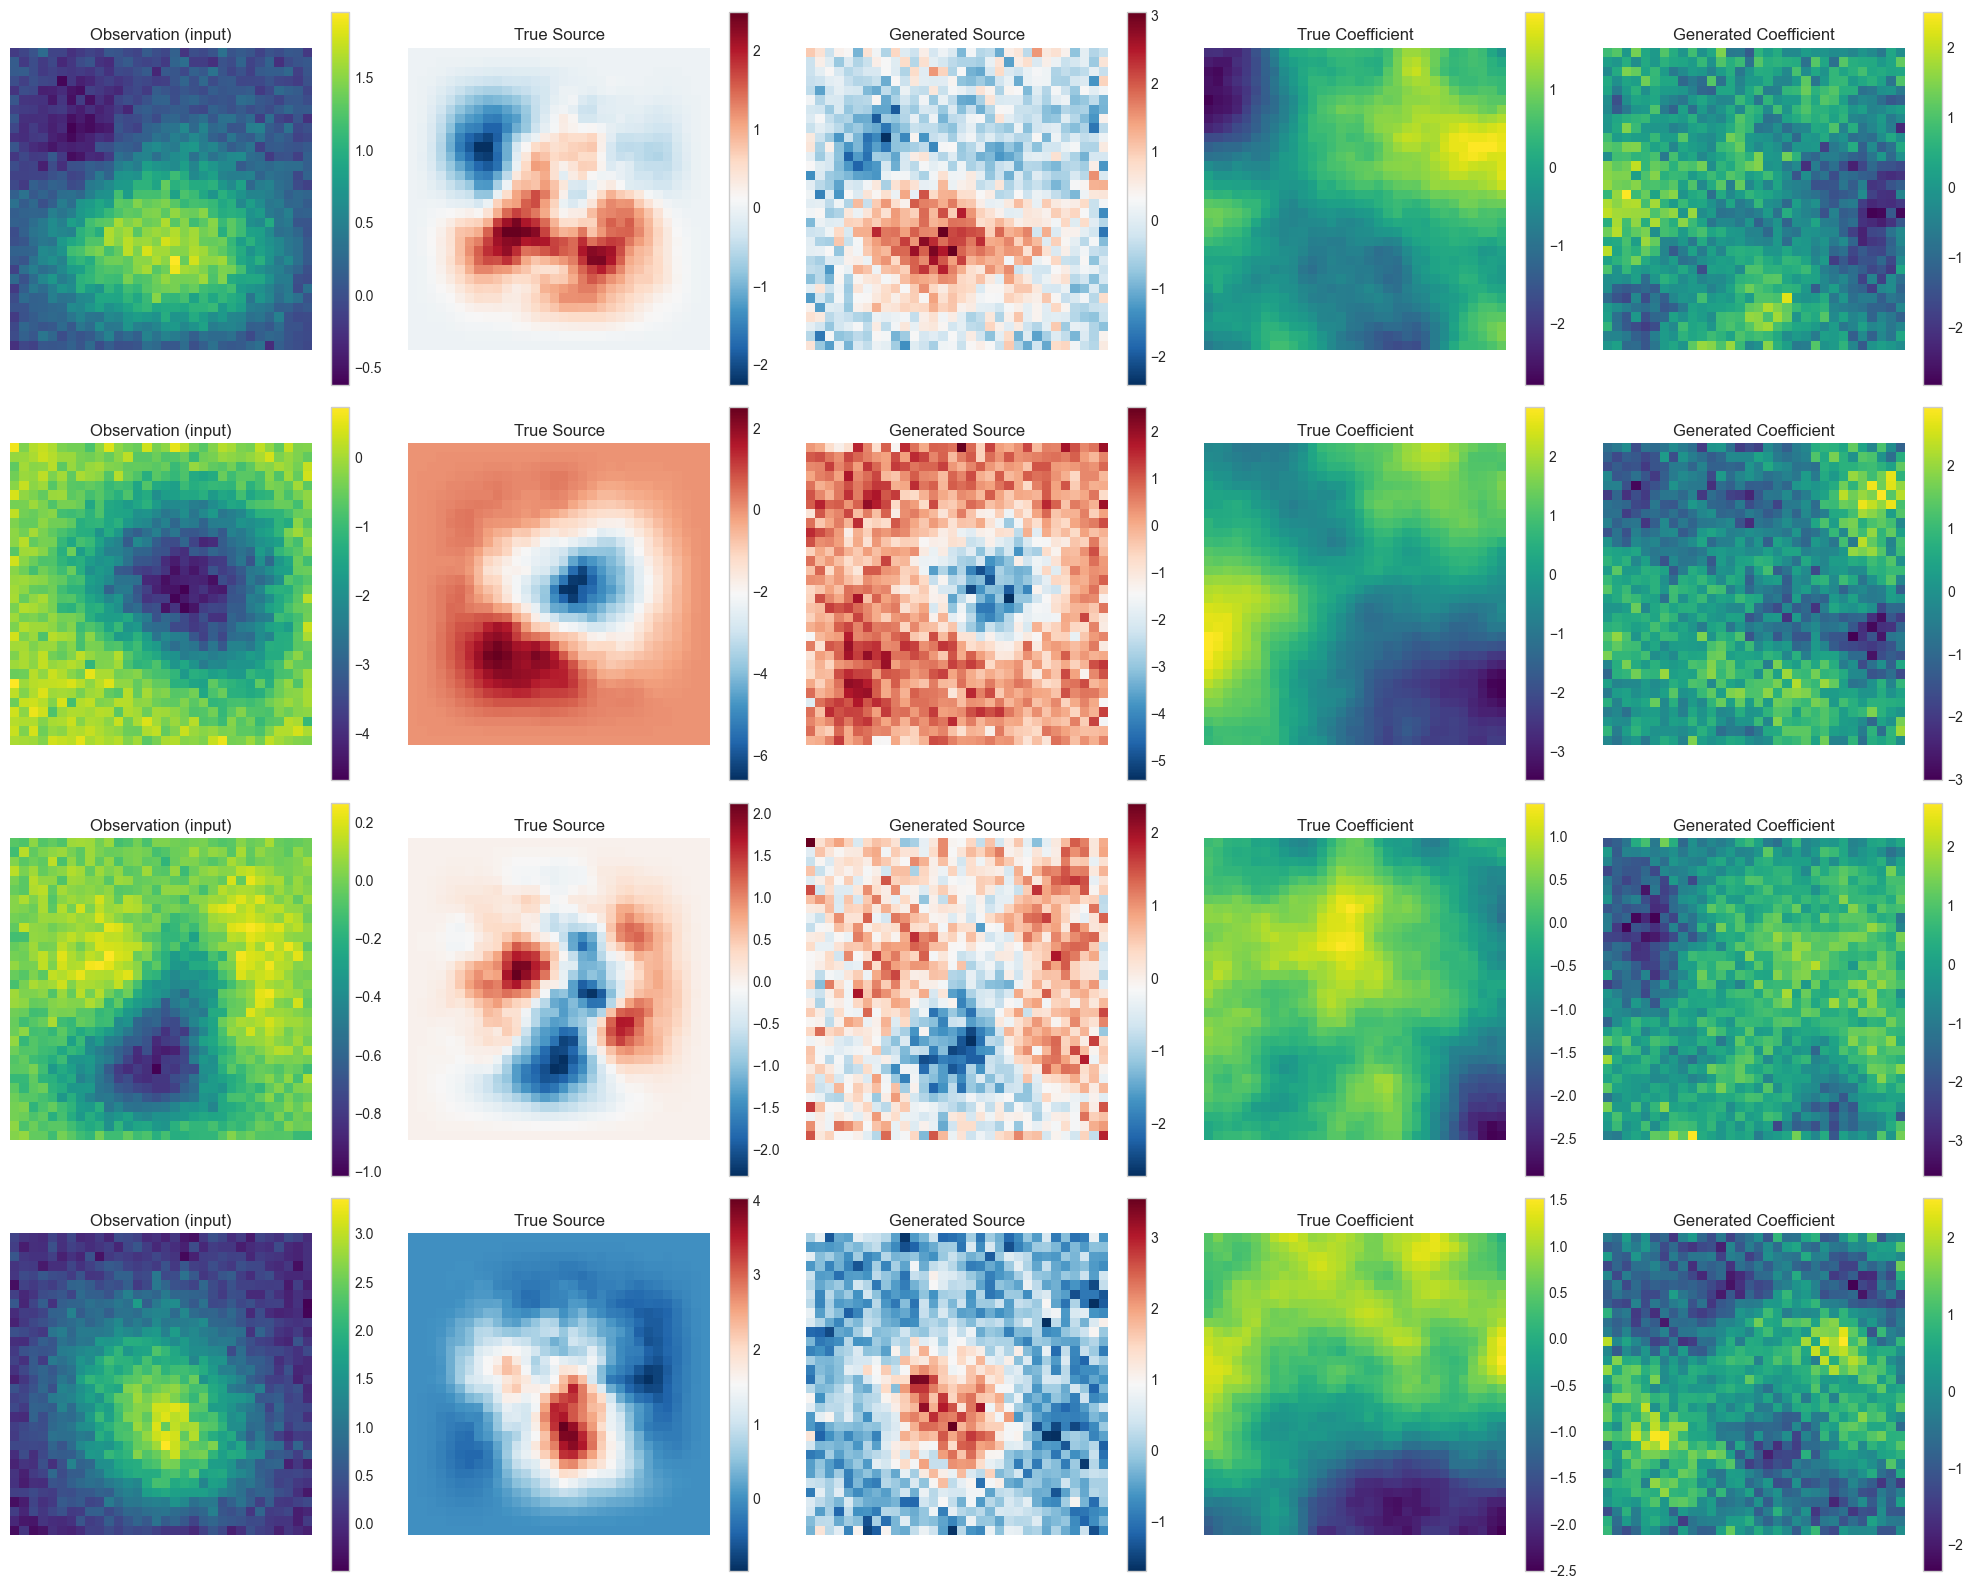


Metrics:
  MSE: 1.081496
  MAE: 0.783693


In [8]:
# Visualize comparison
num_samples = 4
fig, axes = plt.subplots(num_samples, 5, figsize=(20, 4*num_samples))

for i in range(num_samples):
    obs = true_observations[i, 0].cpu().numpy()
    true_source = true_parameters[i, 0].cpu().numpy()
    true_coeff = true_parameters[i, 1].cpu().numpy()
    gen_source = generated_parameters[i, 0].cpu().numpy()
    gen_coeff = generated_parameters[i, 1].cpu().numpy()
    
    # Observation
    im1 = axes[i, 0].imshow(obs, cmap='viridis')
    axes[i, 0].set_title(f'Observation (input)')
    axes[i, 0].axis('off')
    plt.colorbar(im1, ax=axes[i, 0])
    
    # True source
    im2 = axes[i, 1].imshow(true_source, cmap='RdBu_r')
    axes[i, 1].set_title('True Source')
    axes[i, 1].axis('off')
    plt.colorbar(im2, ax=axes[i, 1])
    
    # Generated source
    im3 = axes[i, 2].imshow(gen_source, cmap='RdBu_r')
    axes[i, 2].set_title('Generated Source')
    axes[i, 2].axis('off')
    plt.colorbar(im3, ax=axes[i, 2])
    
    # True coefficient
    im4 = axes[i, 3].imshow(true_coeff, cmap='viridis')
    axes[i, 3].set_title('True Coefficient')
    axes[i, 3].axis('off')
    plt.colorbar(im4, ax=axes[i, 3])
    
    # Generated coefficient
    im5 = axes[i, 4].imshow(gen_coeff, cmap='viridis')
    axes[i, 4].set_title('Generated Coefficient')
    axes[i, 4].axis('off')
    plt.colorbar(im5, ax=axes[i, 4])

plt.tight_layout()
plt.show()

# Compute metrics
mse = ((true_parameters - generated_parameters) ** 2).mean().item()
mae = (true_parameters - generated_parameters).abs().mean().item()

print(f"\nMetrics:")
print(f"  MSE: {mse:.6f}")
print(f"  MAE: {mae:.6f}")

## 9. Uncertainty Quantification

Generate multiple parameter samples for the same observation

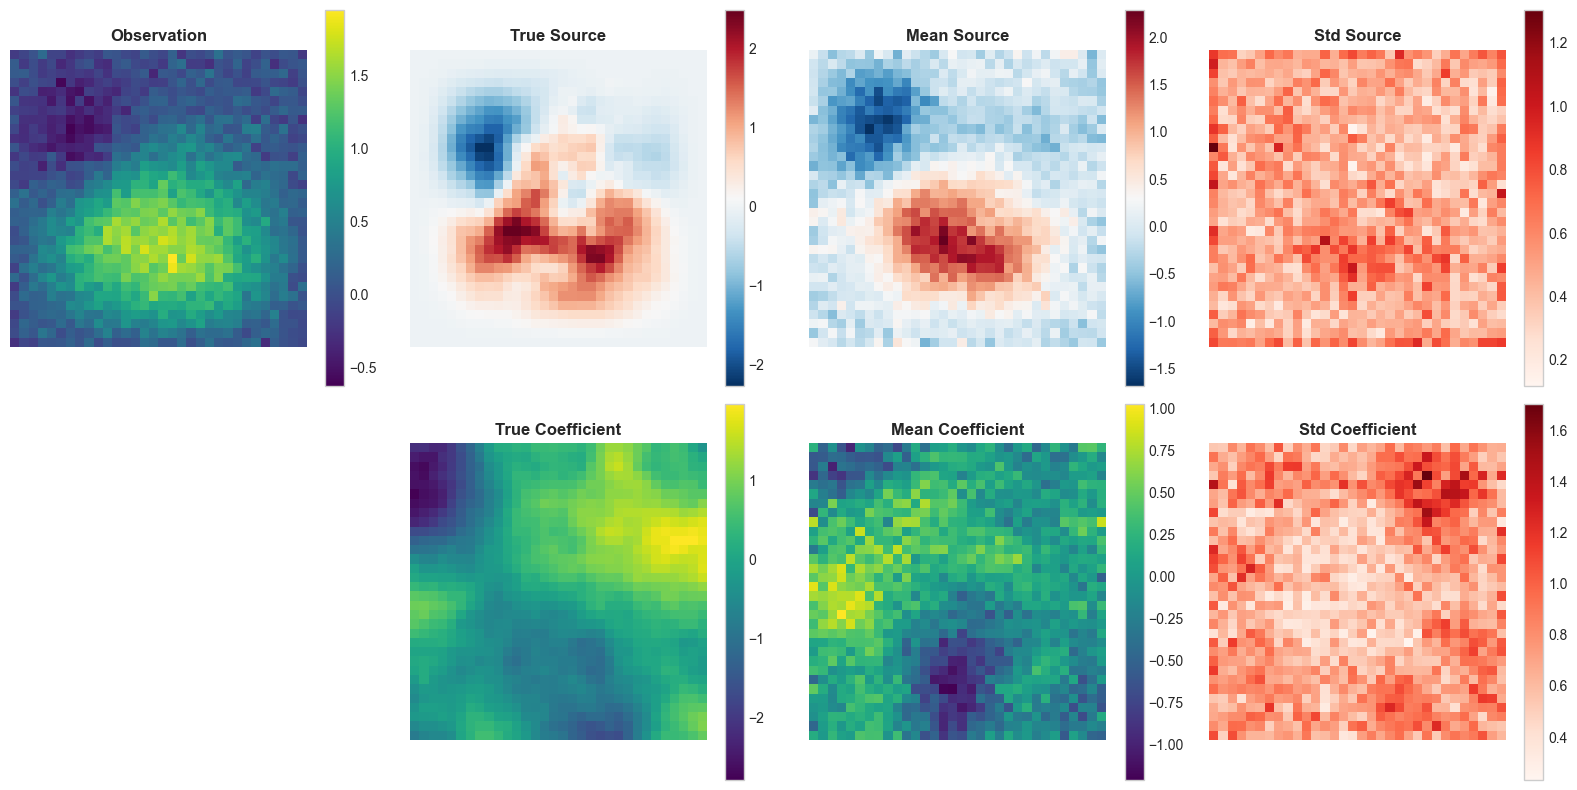


Uncertainty Quantification (from 8 samples):
  Source - Mean MAE: 0.309388
  Source - Avg Std: 0.493146
  Coefficient - Mean MAE: 0.660278
  Coefficient - Avg Std: 0.726397


In [9]:
# Select one observation
idx = 0
single_obs = true_observations[idx:idx+1]
true_params = true_parameters[idx:idx+1]

# Generate multiple samples
num_samples_uq = 8
samples = []

with torch.no_grad():
    for _ in range(num_samples_uq):
        z = torch.randn_like(true_params)
        generated = ode_solver.sample(
            condition=single_obs,
            x_init=z,
            n_steps=50
        )
        samples.append(generated.cpu().numpy())

samples = np.array(samples).squeeze()  # (num_samples, 2, H, W)

# Separate source and coefficient
source_samples = samples[:, 0]  # (num_samples, H, W)
coeff_samples = samples[:, 1]   # (num_samples, H, W)

# Compute statistics
source_mean = source_samples.mean(axis=0)
source_std = source_samples.std(axis=0)
coeff_mean = coeff_samples.mean(axis=0)
coeff_std = coeff_samples.std(axis=0)

# Visualize
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

obs = single_obs[0, 0].cpu().numpy()
true_source = true_params[0, 0].cpu().numpy()
true_coeff = true_params[0, 1].cpu().numpy()

# Row 1: Source
im = axes[0, 0].imshow(obs, cmap='viridis')
axes[0, 0].set_title('Observation', fontweight='bold')
axes[0, 0].axis('off')
plt.colorbar(im, ax=axes[0, 0])

im = axes[0, 1].imshow(true_source, cmap='RdBu_r')
axes[0, 1].set_title('True Source', fontweight='bold')
axes[0, 1].axis('off')
plt.colorbar(im, ax=axes[0, 1])

im = axes[0, 2].imshow(source_mean, cmap='RdBu_r')
axes[0, 2].set_title('Mean Source', fontweight='bold')
axes[0, 2].axis('off')
plt.colorbar(im, ax=axes[0, 2])

im = axes[0, 3].imshow(source_std, cmap='Reds')
axes[0, 3].set_title('Std Source', fontweight='bold')
axes[0, 3].axis('off')
plt.colorbar(im, ax=axes[0, 3])

# Row 2: Coefficient
axes[1, 0].axis('off')

im = axes[1, 1].imshow(true_coeff, cmap='viridis')
axes[1, 1].set_title('True Coefficient', fontweight='bold')
axes[1, 1].axis('off')
plt.colorbar(im, ax=axes[1, 1])

im = axes[1, 2].imshow(coeff_mean, cmap='viridis')
axes[1, 2].set_title('Mean Coefficient', fontweight='bold')
axes[1, 2].axis('off')
plt.colorbar(im, ax=axes[1, 2])

im = axes[1, 3].imshow(coeff_std, cmap='Reds')
axes[1, 3].set_title('Std Coefficient', fontweight='bold')
axes[1, 3].axis('off')
plt.colorbar(im, ax=axes[1, 3])

plt.tight_layout()
plt.show()

print(f"\nUncertainty Quantification (from {num_samples_uq} samples):")
print(f"  Source - Mean MAE: {np.abs(true_source - source_mean).mean():.6f}")
print(f"  Source - Avg Std: {source_std.mean():.6f}")
print(f"  Coefficient - Mean MAE: {np.abs(true_coeff - coeff_mean).mean():.6f}")
print(f"  Coefficient - Avg Std: {coeff_std.mean():.6f}")